In [4]:
import numpy as np

def sample_W_with_target_fro_distance(
    d: int,
    target_dist: float,
) -> np.ndarray:
    E = np.random.rand(d, d)
    fro_E = np.linalg.norm(E, ord="fro")
    E /= fro_E
    W = np.eye(d) + target_dist * E
    return W


def generate_data(n, d, W_fro_dist=0.1, sigma=0.0, seed=0):
    np.random.seed(seed)

    # X_ij ~ N(0, 1/d)
    X = np.random.randn(n, d)/ np.sqrt(d)

    # Construct W with controlled ||W - I||_F
    W = sample_W_with_target_fro_distance(d, W_fro_dist)

    Y_true = X @ W
    Y_noisy = Y_true + sigma * np.random.standard_normal((n, d))

    perm = np.random.permutation(n)
    P = np.eye(n)[perm]          # permutation matrix
    Y_obs = P @ Y_noisy

    return X, Y_obs, W, perm


def fro_norm_W_minus_I(W: np.ndarray) -> float:
    W = np.asarray(W)
    if W.ndim != 2 or W.shape[0] != W.shape[1]:
        raise ValueError(f"W must be square, got {W.shape}")
    I = np.eye(W.shape[0], dtype=W.dtype)
    return float(np.linalg.norm(W - I, ord="fro"))


# Example
n, d = 100, 100
X, Y_obs, W, perm = generate_data(n, d, W_fro_dist=5.9, sigma=0.00, seed=1234)
print("||W - I||_F =", fro_norm_W_minus_I(W))


||W - I||_F = 5.900000000000019


In [5]:
from scipy.optimize import linear_sum_assignment

def recover_permutation(X, Y_obs, max_iter=10):
    n, d = X.shape
    A_hat = np.eye(d)
    for _ in range(max_iter):
        cost_matrix = np.linalg.norm(Y_obs[:, None, :] - X[None, :, :] @ A_hat, axis=2)
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        P_hat = np.zeros((n, n))
        P_hat[row_ind, col_ind] = 1
        A_hat = np.linalg.lstsq(P_hat @ X, Y_obs, rcond=None)[0]
    recovered_perm = np.argmax(P_hat, axis=1)
    return recovered_perm, A_hat

def permutation_accuracy(true_perm, recovered_perm):
    return np.mean(true_perm == recovered_perm)

Processing dims: 100%|██████████| 10/10 [02:33<00:00, 15.31s/it]


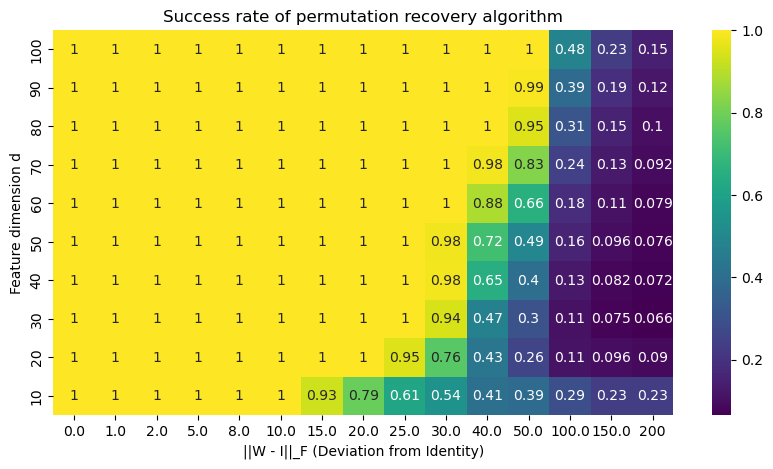

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np

# -----------------------------
# Experiment Grid
# -----------------------------
dims = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]  # reduced for runtime
A_devs = [0.0, 1.0, 2.0, 5.0, 8.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0, 100.0, 150.0, 200]
trials = 50  # reduced for speed
n = 100  # reduced for speed

results = np.zeros((len(dims), len(A_devs)))

for i, d in enumerate(tqdm(dims, desc="Processing dims")):
    for j, dev in enumerate(A_devs):
        accs = []
        for _ in range(trials):
            X, Y_obs, A_true, perm_true = generate_data(n=n, d=d, W_fro_dist=dev, sigma=0.0, seed=i+j+_)
            recovered_perm, _ = recover_permutation(X, Y_obs, max_iter=10)
            accs.append(permutation_accuracy(perm_true, recovered_perm))
        results[i, j] = np.mean(accs)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,5))
sns.heatmap(results, xticklabels=A_devs, yticklabels=dims, annot=True, cmap="viridis")
plt.xlabel("||W - I||_F (Deviation from Identity)")
plt.ylabel("Feature dimension d")
plt.title("Success rate of permutation recovery algorithm")
plt.show()


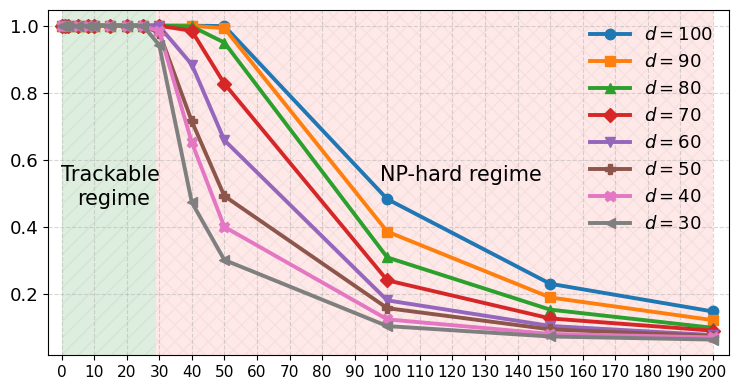

Saved: near_identity_permutation_recovery_d30_d100_ten_iteration_n100_final.pdf


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# REQUIRED INPUTS (you already have these)
#   A_devs: 1D array-like, values on x-axis (should span 0..100)
#   results: 2D array-like, shape = (num_d, len(A_devs))
#            rows correspond to d = 10,20,...,100 (or the reverse; see row_order)
# -----------------------------
x = np.asarray(A_devs, dtype=float)
results = np.asarray(results, dtype=float)

# -----------------------------
# CONFIG
# -----------------------------
d_values = np.arange(100, 9, -10)  # d = 10,20,...,100

# If your results rows are ordered as:
#   "ascending": row 0 -> d=10, row 1 -> d=20, ..., row 9 -> d=100
#   "descending": row 0 -> d=100, row 1 -> d=90, ..., row 9 -> d=10
row_order = "ascending"  # change to "descending" if needed

# vertical threshold line x = x0 (in [0, 100])
x0 =29.0  # <-- set your boundary here

# Define which side is "possible"
possible_side = "left"   # "left" means x <= x0 possible; "right" means x >= x0 possible

# Plot styling
lw = 2.8
ms = 7.5
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>', '*']  # 10 distinct markers

# Output
fig_path = "near_identity_permutation_recovery_d30_d100_ten_iteration_n100_final.pdf"

# -----------------------------
# SANITY CHECKS
# -----------------------------
if results.ndim != 2:
    raise ValueError(f"`results` must be 2D, got shape {results.shape}.")
if x.ndim != 1:
    raise ValueError(f"`A_devs` must be 1D, got shape {x.shape}.")
if results.shape[0] != len(d_values):
    raise ValueError(
        f"`results` must have {len(d_values)} rows (for d=10..100), "
        f"but has {results.shape[0]} rows."
    )
if results.shape[1] != len(x):
    raise ValueError(
        f"`results` must have {len(x)} columns (same as len(A_devs)), "
        f"but has {results.shape[1]} columns."
    )

# align d_values with results row order
if row_order.lower() == "descending":
    d_plot = d_values[::-1]
else:
    d_plot = d_values

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(7.5, 4))
ax = plt.gca()

# Shade regions (different hatching so it’s visually distinct even in grayscale)
if possible_side.lower() == "left":
    ax.axvspan(0, x0, alpha=0.13, hatch='//',  facecolor="green", edgecolor='0.6', linewidth=0.0, zorder=0)
    ax.axvspan(x0, 200, alpha=0.09, hatch='xx', facecolor="red", edgecolor='0.6', linewidth=0.0, zorder=0)
    possible_label_x = 0.5 * x0
    impossible_label_x = x0 + 0.5 * (150 - x0)
    possible_text, impossible_text = "Trackable \nregime", "NP-hard regime"
else:
    ax.axvspan(0, x0, alpha=0.15, hatch='//',  facecolor="green", edgecolor='0.8', linewidth=0.0, zorder=0)
    ax.axvspan(x0, 200, alpha=0.05, hatch='xx', edgecolor='0.8', linewidth=0.0, zorder=0)
    possible_label_x = 0.5 * x0
    impossible_label_x = x0 + 0.5 * (150 - x0)
    possible_text, impossible_text = "Trackable \nregime", "NP-hard regime"

# Threshold line
# ax.axvline(x0, linestyle='--', linewidth=2.2, zorder=2)

# Curves for d=10..100
for i, d in enumerate(d_plot[:8]):
    # i+=7
    ax.plot(
        x, results[i, :],
        marker=markers[i % len(markers)],
        linewidth=lw,
        markersize=ms,
        label=rf"$d={d}$",
        zorder=3
    )

# Axes limits: x from 0 to 100 (as requested)
ax.set_xlim(-4, 205)
ax.set_xticks(np.arange(0, 201, 10))

# If you want fixed y-limits (uncomment if your recovery is in [0,1])
# ax.set_ylim(-0.05, 1.05)f

# Optional labels
# ax.set_xlabel(r"$\|W^\star - I_d\|_F$", fontsize=14)
# ax.set_ylabel("Permutation recovery rate", fontsize=14)

# Region labels (use axis transform so text stays near the top regardless of y-scale)
ax.text(possible_label_x+1.5, 0.55, possible_text, transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=15)
ax.text(impossible_label_x+33, 0.55, impossible_text, transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=15)

# Grid + legend
ax.grid(True, linestyle="--", alpha=0.5)

# Legend can get crowded; this keeps it readable
ax.legend(frameon=False, fontsize=13, loc="upper right", ncol=1, handlelength=2.2)

ax.tick_params(axis='x', which='major', labelsize=11)
ax.tick_params(axis='y', which='major', labelsize=13)

plt.tight_layout()
plt.savefig(fig_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path}")
